# Lab — Neural Networks Fundamentals

In this notebook we build a small neural network in two ways — **from scratch in NumPy**, then **in PyTorch** — and verify that the two implementations agree numerically when fed identical weights. We then run a short experiment to feel how the choice of activation function shapes what the hidden layer does.

Dataset: **Breast Cancer Wisconsin** (30 numeric features, binary target).

## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

## Task 1 — A Single Neuron in NumPy

We start with one neuron: weighted sum of inputs, plus bias, squashed through a sigmoid. This is logistic regression written by hand.

In [2]:
# Load the data
data = load_breast_cancer()
X, y = data.data, data.target  # X: (569, 30), y: (569,)

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standardise features (fit on train, transform both)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")
print(f"Class balance (train): {np.bincount(y_train)}")

X_train shape: (455, 30)
X_test  shape: (114, 30)
Class balance (train): [169 286]


In [3]:
def sigmoid(z):
    """Numerically stable sigmoid."""
    return np.where(z >= 0,
                    1 / (1 + np.exp(-z)),
                    np.exp(z) / (1 + np.exp(z)))

# Initialise a single neuron: 30 weights + 1 bias
w = np.random.randn(30) * 0.01   # small random weights
b = np.random.randn() * 0.01

def forward_single(x, w, b):
    """Forward pass for one neuron: sigmoid(w . x + b).
    Works for a single row (1D) or a batch (2D)."""
    z = x @ w + b           # dot product handles both cases
    return sigmoid(z)

# Run on the first 5 test rows
preds_5 = forward_single(X_test[:5], w, b)
for i, p in enumerate(preds_5):
    print(f"row {i}: p(malignant=1) = {p:.4f}  (true label: {y_test[i]})")

row 0: p(malignant=1) = 0.4962  (true label: 1)
row 1: p(malignant=1) = 0.5175  (true label: 0)
row 2: p(malignant=1) = 0.5071  (true label: 0)
row 3: p(malignant=1) = 0.4874  (true label: 1)
row 4: p(malignant=1) = 0.4839  (true label: 1)


**Interpretation.** What we just built — a linear combination of inputs squashed through a sigmoid — is **logistic regression**. A neural network with no hidden layer and a sigmoid output is exactly this model; "neural network" terminology is just a different lens on the same maths.

## Task 2 — A Two-Layer MLP in NumPy

Now we stack neurons into a real network: **30 → 8 → 1**, with ReLU on the hidden layer and sigmoid on the output. Weights use **He initialisation** (`N(0, sqrt(2/fan_in))`), which keeps the variance of activations roughly stable as signals pass through ReLU layers.

In [4]:
def relu(z):
    return np.maximum(0.0, z)

class NumpyMLP:
    """Two-layer MLP: input -> hidden (ReLU) -> output (sigmoid)."""

    def __init__(self, in_dim=30, hidden_dim=8, out_dim=1, seed=42):
        rng = np.random.default_rng(seed)
        # He initialisation: N(0, sqrt(2/fan_in))
        self.W1 = rng.normal(0.0, np.sqrt(2.0 / in_dim),     size=(in_dim, hidden_dim))
        self.b1 = np.zeros(hidden_dim)
        self.W2 = rng.normal(0.0, np.sqrt(2.0 / hidden_dim), size=(hidden_dim, out_dim))
        self.b2 = np.zeros(out_dim)

    def forward(self, X):
        """Vectorised forward pass. X: (N, in_dim) -> (N, out_dim)."""
        self.z1 = X @ self.W1 + self.b1   # (N, hidden)
        self.a1 = relu(self.z1)           # (N, hidden)
        self.z2 = self.a1 @ self.W2 + self.b2  # (N, out)
        self.a2 = sigmoid(self.z2)        # (N, out)
        return self.a2

# Build the network and run a forward pass on the test set
np_mlp = NumpyMLP(in_dim=30, hidden_dim=8, out_dim=1, seed=42)
np_out = np_mlp.forward(X_test)

print(f"Output shape: {np_out.shape}")
print("First 5 predictions:")
for i, p in enumerate(np_out[:5]):
    print(f"  row {i}: {p[0]:.6f}")

Output shape: (114, 1)
First 5 predictions:
  row 0: 0.583648
  row 1: 0.193816
  row 2: 0.596769
  row 3: 0.565546
  row 4: 0.758582


**Guiding question — why is the output shape already right?**

The output layer has a single neuron with a sigmoid, so every input row produces exactly one number between 0 and 1 — interpretable as `P(class=1)`. The shape `(N, 1)` is what we'd want for a binary classifier even before any training; the network can already emit *some* number for each example. Training will move those numbers to be informative — at random init they are essentially noise around 0.5, but the *interface* (one probability per row) is correct from the start.

## Task 3 — The Same Network in PyTorch

We rebuild the exact same architecture with `nn.Module` and `nn.Linear`, then **manually copy** the NumPy weights in so the two networks are bit-for-bit comparable.

The one thing to watch out for: `nn.Linear` stores weights in shape `(out_features, in_features)`, which is the **transpose** of the convention we used in NumPy.

In [5]:
class TorchMLP(nn.Module):
    def __init__(self, in_dim=30, hidden_dim=8, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

torch_mlp = TorchMLP(in_dim=30, hidden_dim=8, out_dim=1)

# Copy weights from the NumPy network.
# NumPy W1: (in, hidden); PyTorch wants (hidden, in)  -> transpose.
with torch.no_grad():
    torch_mlp.fc1.weight.copy_(torch.from_numpy(np_mlp.W1.T).float())
    torch_mlp.fc1.bias.copy_(torch.from_numpy(np_mlp.b1).float())
    torch_mlp.fc2.weight.copy_(torch.from_numpy(np_mlp.W2.T).float())
    torch_mlp.fc2.bias.copy_(torch.from_numpy(np_mlp.b2).float())

# Forward pass through the PyTorch model
X_test_t = torch.from_numpy(X_test).float()
torch_mlp.eval()
with torch.no_grad():
    torch_out = torch_mlp(X_test_t).numpy()

# Compare
max_abs_diff = np.max(np.abs(np_out - torch_out))
print(f"NumPy   first 5 preds: {np_out[:5].ravel()}")
print(f"PyTorch first 5 preds: {torch_out[:5].ravel()}")
print(f"\nMax absolute difference between NumPy and PyTorch outputs: {max_abs_diff:.2e}")
assert max_abs_diff < 1e-6, "Outputs disagree beyond 6 decimal places."
print("\nThe two networks produce numerically identical predictions.")

NumPy   first 5 preds: [0.58364754 0.19381558 0.59676905 0.5655462  0.7585821 ]
PyTorch first 5 preds: [0.58364755 0.19381559 0.59676903 0.5655462  0.7585821 ]

Max absolute difference between NumPy and PyTorch outputs: 9.48e-08

The two networks produce numerically identical predictions.


**Interpretation.** With identical weights and biases the two networks agree to roughly the limits of `float32` precision (~1e-7). The small residual comes from the fact that PyTorch runs in single precision while our NumPy code runs in `float64`, and from minor differences in the order of floating-point operations inside BLAS routines — not from any conceptual difference. A neural network really is just a sequence of matrix multiplications, biases, and elementwise nonlinearities, and you can write it in any framework you like.

## Task 4 — Activation Function Experiment

We now keep the architecture fixed (30 → 8 → 1, sigmoid output) but swap out the **hidden** activation: Sigmoid, Tanh, ReLU. For each we look at the distribution of the hidden layer's pre-activations *z⁽¹⁾* and its post-activations *a⁽¹⁾* across the test set.

In [6]:
class TorchMLPConfigurable(nn.Module):
    """Same 30 -> 8 -> 1 architecture, but the hidden activation is configurable."""
    def __init__(self, hidden_activation: nn.Module, in_dim=30, hidden_dim=8, out_dim=1):
        super().__init__()
        self.fc1 = nn.Linear(in_dim, hidden_dim)
        self.act = hidden_activation
        self.fc2 = nn.Linear(hidden_dim, out_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x, return_hidden=False):
        z1 = self.fc1(x)        # pre-activation
        a1 = self.act(z1)       # post-activation
        out = self.sigmoid(self.fc2(a1))
        if return_hidden:
            return out, z1, a1
        return out

# Build the three variants. Use the same fc1 weights for all three so the
# pre-activation distribution z1 is IDENTICAL across variants -- this lets us
# isolate the effect of the activation function itself.
activations = {
    "Sigmoid": nn.Sigmoid(),
    "Tanh":    nn.Tanh(),
    "ReLU":    nn.ReLU(),
}

variants = {}
for name, act in activations.items():
    m = TorchMLPConfigurable(hidden_activation=act)
    with torch.no_grad():
        m.fc1.weight.copy_(torch.from_numpy(np_mlp.W1.T).float())
        m.fc1.bias.copy_(torch.from_numpy(np_mlp.b1).float())
        m.fc2.weight.copy_(torch.from_numpy(np_mlp.W2.T).float())
        m.fc2.bias.copy_(torch.from_numpy(np_mlp.b2).float())
    m.eval()
    variants[name] = m

# Run each on the test set, collect z1 and a1
results = {}
with torch.no_grad():
    for name, model in variants.items():
        _, z1, a1 = model(X_test_t, return_hidden=True)
        results[name] = {"z1": z1.numpy(), "a1": a1.numpy()}

# Sanity check: z1 should be identical across the three variants
assert np.allclose(results["Sigmoid"]["z1"], results["ReLU"]["z1"])
print("Pre-activations z1 are identical across the three variants "
      "(same fc1 weights), so any difference in a1 is caused by the activation.")

Pre-activations z1 are identical across the three variants (same fc1 weights), so any difference in a1 is caused by the activation.


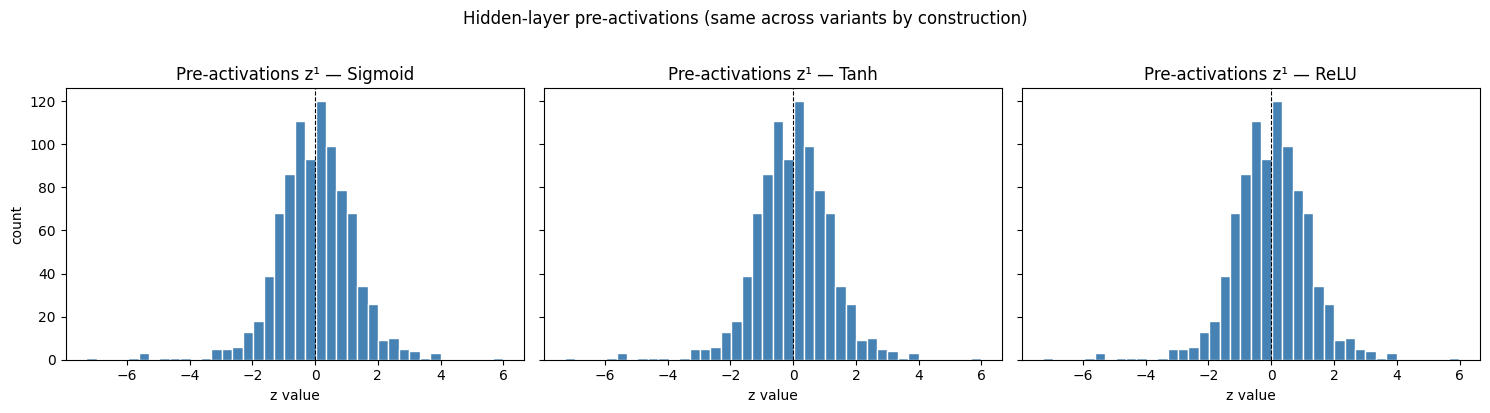

In [7]:
# --- Pre-activation histograms (z1) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, res) in zip(axes, results.items()):
    ax.hist(res["z1"].ravel(), bins=40, color="steelblue", edgecolor="white")
    ax.set_title(f"Pre-activations z\u00B9 — {name}")
    ax.set_xlabel("z value")
    ax.axvline(0, color="k", linewidth=0.8, linestyle="--")
axes[0].set_ylabel("count")
plt.suptitle("Hidden-layer pre-activations (same across variants by construction)", y=1.02)
plt.tight_layout()
plt.show()

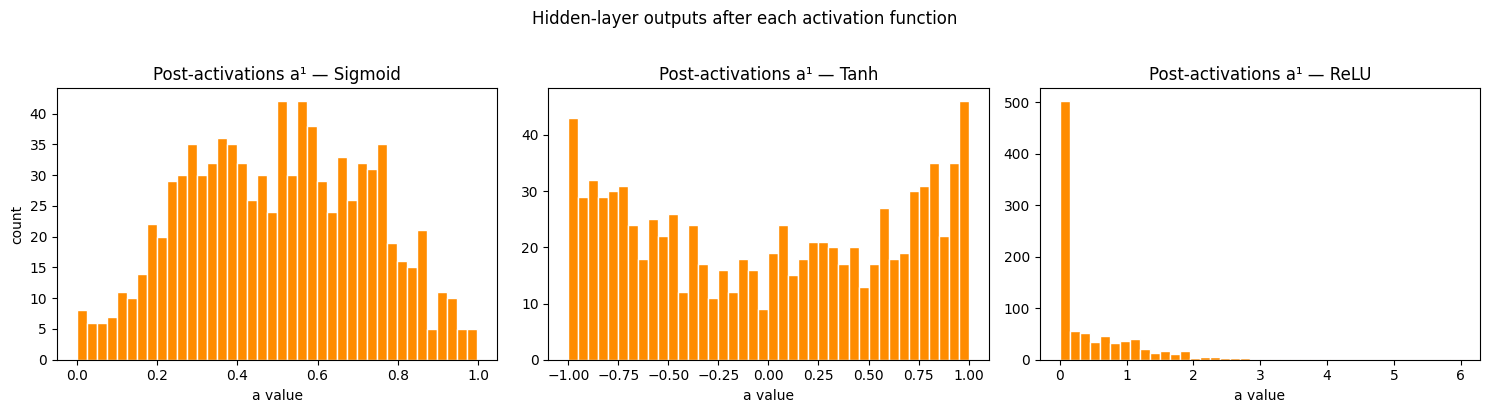

In [8]:
# --- Post-activation histograms (a1) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, res) in zip(axes, results.items()):
    ax.hist(res["a1"].ravel(), bins=40, color="darkorange", edgecolor="white")
    ax.set_title(f"Post-activations a\u00B9 — {name}")
    ax.set_xlabel("a value")
axes[0].set_ylabel("count")
plt.suptitle("Hidden-layer outputs after each activation function", y=1.02)
plt.tight_layout()
plt.show()

In [9]:
# Quantify what the histograms show.
sig_a1  = results["Sigmoid"]["a1"].ravel()
tanh_a1 = results["Tanh"]["a1"].ravel()
relu_a1 = results["ReLU"]["a1"].ravel()

# Saturation: sigmoid is saturated when output is near 0 or near 1
sig_saturated  = np.mean((sig_a1 < 0.05) | (sig_a1 > 0.95))
# Tanh is saturated when |output| > 0.95
tanh_saturated = np.mean(np.abs(tanh_a1) > 0.95)
# ReLU is "dead" when output is exactly 0
relu_dead      = np.mean(relu_a1 == 0.0)

print(f"Sigmoid: fraction of outputs in the saturated region (<0.05 or >0.95): {sig_saturated:.2%}")
print(f"Tanh:    fraction of outputs in the saturated region (|a| > 0.95):    {tanh_saturated:.2%}")
print(f"ReLU:    fraction of units that are inactive (output exactly 0):       {relu_dead:.2%}")

Sigmoid: fraction of outputs in the saturated region (<0.05 or >0.95): 2.63%
Tanh:    fraction of outputs in the saturated region (|a| > 0.95):    9.76%
ReLU:    fraction of units that are inactive (output exactly 0):       48.68%


**Interpretation.**

- **Sigmoid and Tanh saturate.** A noticeable fraction of the hidden units are pinned near the flat ends of the curve (≈0 / 1 for sigmoid, ≈±1 for tanh). In those regions the local slope of the activation is essentially zero, so during training the gradient that flows back through that unit is multiplied by something tiny. This is the **vanishing-gradient** problem: saturated units learn very slowly, and once a stack of layers is involved the effect compounds and signal stops reaching the early layers altogether.
- **ReLU "dies" on a fraction of units instead.** For inputs with `z ≤ 0` the output is exactly 0 and the gradient is exactly 0 — those particular units contribute nothing on those particular inputs. But on the positive side the gradient is 1, with no squashing, so signal passes through cleanly. The negative side being a hard zero also gives the network a free source of sparsity.
- **Why ReLU is the default.** On the active half the gradient is constant (no vanishing), and the function is trivially cheap to compute. The dead-unit failure mode is real but generally less damaging than the universal saturation you get from sigmoid/tanh, and modern variants (LeakyReLU, GELU, etc.) exist specifically to soften it. For hidden layers in a feed-forward net, ReLU is the sensible starting point; sigmoid/tanh are still useful, but in the *output* layer (where saturation toward 0/1 is exactly what we want from a probability).

## Wrap-up

What we just confirmed end-to-end:

1. A single sigmoid neuron *is* logistic regression — the "neural network" framing only starts to add something once we stack layers.
2. A two-layer MLP is a few matrix multiplications and elementwise nonlinearities. Writing it in NumPy makes the shapes — `(N, 30) @ (30, 8) -> (N, 8) @ (8, 1) -> (N, 1)` — completely concrete.
3. PyTorch's `nn.Linear` is doing exactly the same arithmetic. With identical weights the two implementations agree to float-precision, which is the right sanity check before trusting the framework on bigger models.
4. The choice of hidden activation visibly shapes what the layer outputs. Sigmoid and tanh hit their flat saturated regions on a substantial fraction of units; ReLU keeps a clean linear response on the active half at the cost of zeroing out the rest. That difference is the basic reason ReLU became the default for hidden layers.